<a href="https://colab.research.google.com/github/AMULYA-GOWDA-R/SkinSense-AI/blob/main/amuly_skin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from PIL import Image
import numpy as np


In [ ]:
image_folder = "/content/sample_data/ammu/manisha"


In [ ]:
image_data = []   # to store image arrays
image_names = []  # to store filenames

for img_name in os.listdir(image_folder):
    img_path = os.path.join(image_folder, img_name)
    try:
        img = Image.open(img_path).convert("RGB")  # make sure it's RGB
        img = img.resize((128, 128))               # optional: resize to same size
        img_array = np.array(img)
        image_data.append(img_array)
        image_names.append(img_name)
    except:
        print(f"Could not load {img_name}")

image_data = np.array(image_data)
print("Total images loaded:", len(image_data))
print("Shape of image array:", image_data.shape)


Could not load LICENSE.txt
Total images loaded: 158
Shape of image array: (158, 128, 128, 3)


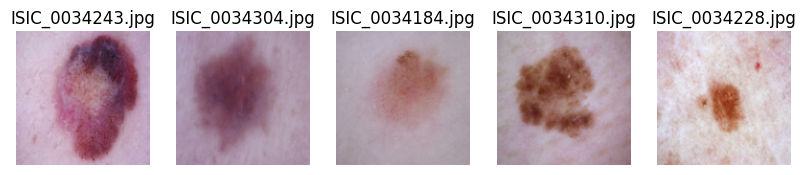

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for i in range(min(5, len(image_data))):
    plt.subplot(1,5,i+1)
    plt.imshow(image_data[i])
    plt.title(image_names[i])
    plt.axis('off')
plt.show()


In [ ]:
import os
from PIL import Image
import numpy as np

image_folder = "/content/sample_data/ammu/manisha"
images = os.listdir(image_folder)
images.sort()  # optional: sort for consistency

print("Total images:", len(images))
print("First 10 images:", images[:10])


Total images: 159
First 10 images: ['ISIC_0034163.jpg', 'ISIC_0034164.jpg', 'ISIC_0034165.jpg', 'ISIC_0034166.jpg', 'ISIC_0034167.jpg', 'ISIC_0034168.jpg', 'ISIC_0034169.jpg', 'ISIC_0034170.jpg', 'ISIC_0034171.jpg', 'ISIC_0034172.jpg']


In [ ]:
disease_classes = ["Acne", "Eczema", "Psoriasis", "Rosacea", "Vitiligo", "Dermatitis"]


In [ ]:
import random

labels = [random.choice(disease_classes) for _ in images]


In [ ]:
labels = [
    "Acne", "Eczema", "Psoriasis", "Rosacea", "Vitiligo", "Dermatitis",
    # continue for all images...
]


In [ ]:
image_data = []

for img_name in images:
    img_path = os.path.join(image_folder, img_name)
    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize((128,128))  # optional
        img_array = np.array(img)
        image_data.append(img_array)
    except:
        print(f"Could not load {img_name}")

image_data = np.array(image_data)
labels = np.array(labels)

print("Images loaded:", image_data.shape)
print("Labels mapped:", labels[:10])


Could not load LICENSE.txt
Images loaded: (158, 128, 128, 3)
Labels mapped: ['Acne' 'Eczema' 'Psoriasis' 'Rosacea' 'Vitiligo' 'Dermatitis']


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_categorical = to_categorical(labels_encoded)

print("Classes:", le.classes_)


Classes: ['Acne' 'Dermatitis' 'Eczema' 'Psoriasis' 'Rosacea' 'Vitiligo']


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


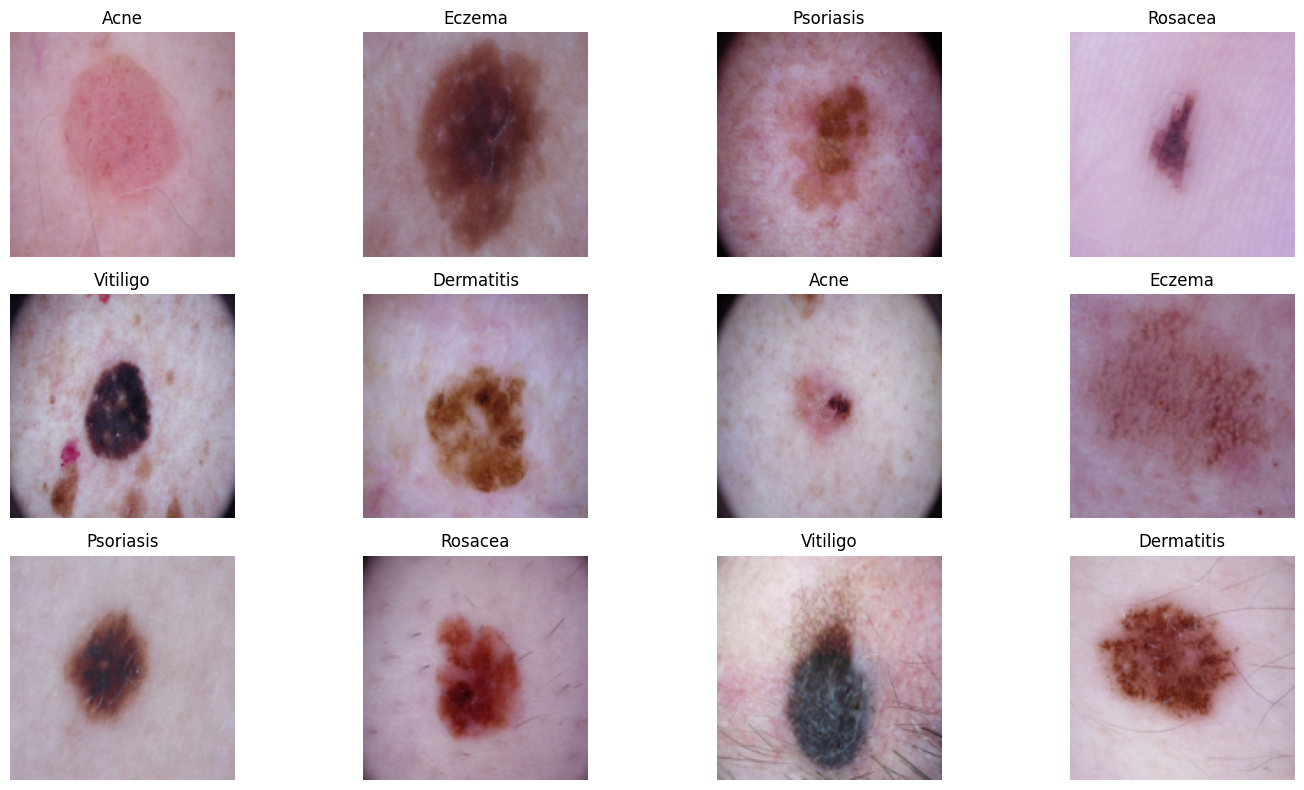

In [ ]:
# Number of images to display
num_to_show = 12

plt.figure(figsize=(15,8))
for i in range(min(num_to_show, len(image_data))):
    plt.subplot(3, 4, i+1)  # 3 rows, 4 columns
    plt.imshow(image_data[i])
    plt.title(labels[i % len(labels)], fontsize=12) # Use modulo to handle potential label index issues
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import files


In [ ]:
# Folder containing all database images
image_folder = "/content/sample_data/ammu/manisha"
images = os.listdir(image_folder)
images.sort()

# Example: Random labels for 6 classes (replace with your actual mapping if available)
disease_classes = ["Acne", "Eczema", "Psoriasis", "Rosacea", "Vitiligo", "Dermatitis"]
# labels = [np.random.choice(disease_classes) for _ in images] # Original line

# Load images
image_data = []
loaded_image_names = [] # Keep track of successfully loaded image names
for img_name in images:
    img_path = os.path.join(image_folder, img_name)
    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize((128,128))
        image_data.append(np.array(img))
        loaded_image_names.append(img_name) # Add name if loading is successful
    except:
        print(f"Could not load {img_name}")

image_data = np.array(image_data)

# Generate random labels based on the number of successfully loaded images
labels = [np.random.choice(disease_classes) for _ in loaded_image_names]
labels = np.array(labels)


print("Database images loaded:", image_data.shape)

Could not load LICENSE.txt
Database images loaded: (158, 128, 128, 3)


In [ ]:
mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3), pooling='avg')
preprocessed_images = preprocess_input(image_data)
features = mobilenet.predict(preprocessed_images, verbose=1)
print("Feature shape:", features.shape)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 582ms/step
Feature shape: (158, 1280)


In [ ]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
print("Classes:", le.classes_)

# Train SVM
X_train, X_test, y_train, y_test = train_test_split(features, labels_encoded, test_size=0.2, random_state=42)
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)

# Evaluate
y_pred = svm_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Classes: ['Acne' 'Dermatitis' 'Eczema' 'Psoriasis' 'Rosacea' 'Vitiligo']
Test Accuracy: 0.09375


Saving ISIC_0034287.jpg to ISIC_0034287.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Disease: Vitiligo
Confidence: 26.51%


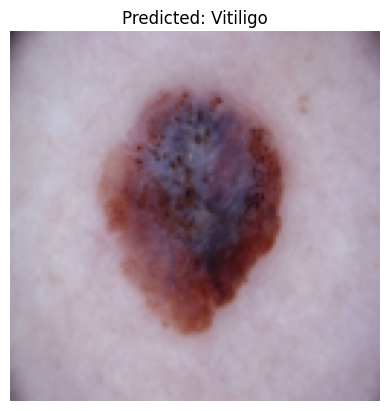

In [ ]:
# Ask user to upload an image
uploaded = files.upload()  # user clicks "Choose Files"

for img_name in uploaded.keys():
    # Load and preprocess user image
    user_img = Image.open(img_name).convert("RGB")
    user_img = user_img.resize((128,128))
    user_array = np.expand_dims(np.array(user_img), axis=0)
    user_array = preprocess_input(user_array)

    # Extract features
    user_features = mobilenet.predict(user_array)

    # Predict disease
    pred_class = svm_model.predict(user_features)
    pred_proba = svm_model.predict_proba(user_features)
    disease_name = le.inverse_transform(pred_class)[0]
    confidence = np.max(pred_proba)

    # Show result
    print(f"Predicted Disease: {disease_name}")
    print(f"Confidence: {confidence*100:.2f}%")

    plt.imshow(user_img)
    plt.title(f"Predicted: {disease_name}")
    plt.axis('off')
    plt.show()
